# 1. Calculate all distances
- pc4 (46,870,226 million edges): 6 seconds

In [1]:
import ibis
import pandas as pd
from utils.f_0_dirs import get_data_dirs
from pathlib import Path

table_in_name = "working_fixed"
table_out_name = "working_distance"
# Limiting group property: any firms that don't share (string match) this variable have null in distance values, i.e. not potential peers.
prop = "pc4"  # 4-digit postcode prefix

# ==========================================
# 1. SETUP & EXTENSION LOADING
# ==========================================
dirs = get_data_dirs()
print("⏳ Initializing DuckDB connection and loading spatial extension...")
start_time = pd.Timestamp.now()

# Assuming dirs.db_path is defined
con = ibis.duckdb.connect(dirs.db_path)
con.raw_sql("INSTALL spatial; LOAD spatial;")

print(f"✅ Database connected in {(pd.Timestamp.now() - start_time).total_seconds():.1f} seconds.\n")

# ==========================================
# 2. THE IBIS ORM PIPELINE (AST Building)
# ==========================================
print("⏳ Building Ibis relational algebra (Lazy Evaluation)...")
ast_start = pd.Timestamp.now()

t = con.table(table_in_name)

# Filter non-nulls and non-zeroes for the relevant columns
t_clean = t.filter([
    t.lon_dec.notnull() & (t.lon_dec != 0),
    t.lat_dec.notnull() & (t.lat_dec != 0),
    t[prop].notnull()
])

# Aliases for the Self-Join
left = t_clean.alias("a")
right = t_clean.alias("b")

# Block-Diagonal Join & Diagonal Filter 
joined = left.join(
    right,
    [
        left[prop] == right[prop],                             # Block-Diagonal
        left.registered_number != right.registered_number  # Exclude self-pairs
    ]
)

# Project the required columns
pairs = joined.select(
    firm_i = left.registered_number,
    firm_j = right.registered_number,
    prop_key = left[prop],
    lon_i = left.lon_dec,
    lat_i = left.lat_dec,
    lon_j = right.lon_dec,
    lat_j = right.lat_dec
)

# Register the Ibis logic as a virtual table (No data processed yet)
con.create_view("temp_spatial_pairs", pairs, overwrite=True)
print(f"✅ Ibis AST built and view registered in {(pd.Timestamp.now() - ast_start).total_seconds():.1f} seconds.\n")

# ==========================================
# 3. RAW SQL SPATIAL WRAPPER & MATERIALIZATION
# ==========================================
print("⏳ Starting out-of-core physical materialization to disk. This may take a minute...")
exec_start = pd.Timestamp.now()

# Apply the ST_Point and ST_Distance_Sphere logic to the Ibis view.
spatial_matrix_expr = con.sql(f"""
    SELECT 
        firm_i,
        firm_j,
        prop_key AS {prop},
        ST_Distance_Sphere(
            ST_Point(lon_i, lat_i), 
            ST_Point(lon_j, lat_j)
        ) AS distance_meters
    FROM temp_spatial_pairs
""")

# Execute the entire unified plan out-of-core
con.create_table(table_out_name, spatial_matrix_expr, overwrite=True)

exec_duration = pd.Timestamp.now() - exec_start
print(f"✅ Materialization complete in {exec_duration.total_seconds():.1f} seconds.\n")

# ==========================================
# 4. VERIFICATION
# ==========================================
print("⏳ Verifying output...")
row_count = con.table(table_out_name).count().execute()

print(f"🎉 SUCCESS! Total edges calculated: {row_count:,}")
print(f"⏱️ Total script execution time: {(pd.Timestamp.now() - start_time).total_seconds():.1f} seconds.\n")

# Optional: Peek at the data
display(con.table(table_out_name).head(5).execute())

⏳ Initializing DuckDB connection and loading spatial extension...
✅ Database connected in 1.5 seconds.

⏳ Building Ibis relational algebra (Lazy Evaluation)...
✅ Ibis AST built and view registered in 0.0 seconds.

⏳ Starting out-of-core physical materialization to disk. This may take a minute...
✅ Materialization complete in 5.6 seconds.

⏳ Verifying output...
🎉 SUCCESS! Total edges calculated: 46,870,226
⏱️ Total script execution time: 7.2 seconds.



,firm_i,firm_j,pc4,distance_meters
0,04706935,02710265,EC1V,376.079585
1,06873977,02710265,EC1V,930.287073
2,03283581,02710265,EC1V,826.365636
3,04330100,02710265,EC1V,812.058728
4,04944709,02710265,EC1V,726.387891


In [3]:
con.raw_sql("CHECKPOINT;")
con.disconnect()

ConnectionException: Connection Error: Connection already closed!

# 2. [read] summary stats: generated distances table

In [12]:
import ibis
from ibis import _
from utils.f_0_dirs import get_data_dirs

table_in_name = "working_fixed"
table_out_name = "working_distance"

dirs = get_data_dirs(segment="descriptives")
con = ibis.duckdb.connect(dirs.db_path, read_only=True)
table_out = con.table(table_out_name)
table_fixed = con.table(table_in_name).select("registered_number", "pc8", "lat_lon5", "address_lvl", "address_case")
tf_i = table_fixed.alias("tf_i")
tf_j = table_fixed.alias("tf_j")

# 3. Perform double left join and explicitly select/rename columns
table_joined = (
    table_out
    .left_join(tf_i, table_out.firm_i == tf_i.registered_number)
    .rename({f"{col}_i": f"{col}" for col in tf_i.columns})
    .left_join(tf_j, table_out.firm_j == tf_j.registered_number)
    .rename({f"{col}_j": f"{col}" for col in tf_j.columns})
)

# Display sample of 500 random rows
table_sample = table_joined.sample(10 / table_joined.count().execute()).execute()
display(table_sample)

# Show largest 50 distances
table_largest = table_joined.order_by(table_joined.distance_meters.desc()).limit(10).execute()
display(table_largest)

,firm_i,firm_j,pc4,distance_meters,registered_number_i,pc8_i,lat_lon5_i,address_lvl_i,address_case_i,registered_number_j,pc8_j,lat_lon5_j,address_lvl_j,address_case_j
0,00151665,08735617,NN4,2280.919357,00151665,NN4 7YJ,"52.21747,-0.88025",1,pta,08735617,NN4 7YB,"52.22818,-0.86275",2,ro
1,11450807,02825694,EC4M,2006.544564,11450807,EC4M 9AF,"51.50536,-0.08828",1,pta,02825694,EC4M 7RB,"51.51514,-0.10344",1,ro
2,06257540,08706238,EC4M,94365.471497,06257540,EC4M 7AN,"52.04064,-0.76983",1,pta,08706238,EC4M 7RB,"51.51514,-0.10344",1,ro
3,07033895,07930340,SL6,10467.012286,07033895,SL6 6RJ,"51.52953,-0.81142",1,pta,07930340,SL6 3LE,"51.48522,-0.72836",1,pta
4,06638094,08807801,MK42,3703.630579,06638094,MK42 9LA,"52.12794,-0.46289",1,ro,08807801,MK42 7SH,"52.10911,-0.49036",1,pta
5,04014628,01975062,BS1,641.336691,04014628,BS1 6AJ,"51.45321,-2.58799",2,ro,01975062,BS1 2NT,"51.45853,-2.58575",1,pta
6,SC467268,SC328499,AB12,6670.475461,SC467268,AB12 4XX,"57.07698,-2.12463",2,ro,SC328499,AB12 3PG,"57.11058,-2.07492",1,pta
7,03487621,03664551,SE1,6963.809245,03487621,SE1 9QR,"51.50636,-0.08863",2,ro,03664551,SE1 8RT,"51.51608,-0.1505",1,pta


,firm_i,firm_j,pc4,distance_meters,registered_number_i,pc8_i,lat_lon5_i,address_lvl_i,address_case_i,registered_number_j,pc8_j,lat_lon5_j,address_lvl_j,address_case_j
0,NI037243,04494730,,768851.075890,NI037243,,"55.05914,-6.31494",1,pta,04494730,,"51.37239,-0.46031",1,ro
1,04494730,NI037243,,768851.075890,04494730,,"51.37239,-0.46031",1,ro,NI037243,,"55.05914,-6.31494",1,pta
2,03241146,NI037243,,734991.204212,03241146,,"51.91181,-0.49867",1,pta,NI037243,,"55.05914,-6.31494",1,pta
3,NI037243,03241146,,734991.204212,NI037243,,"55.05914,-6.31494",1,pta,03241146,,"51.91181,-0.49867",1,pta
4,NI047139,NI046813,BT36,717229.700574,NI047139,BT36 4RB,"54.68792,-6.02356",1,pta,NI046813,BT36 4RF,"51.55844,-0.37997",1,pta
5,NI008627,NI046813,BT36,717229.700574,NI008627,BT36 4RB,"54.68792,-6.02356",1,pta,NI046813,BT36 4RF,"51.55844,-0.37997",1,pta
6,NI054518,NI053848,BT36,717229.700574,NI054518,BT36 4RE,"51.55844,-0.37997",1,pta,NI053848,BT36 4RE,"54.68792,-6.02356",1,pta
7,NI053848,NI046813,BT36,717229.700574,NI053848,BT36 4RE,"54.68792,-6.02356",1,pta,NI046813,BT36 4RF,"51.55844,-0.37997",1,pta
8,NI046813,NI047139,BT36,717229.700574,NI046813,BT36 4RF,"51.55844,-0.37997",1,pta,NI047139,BT36 4RB,"54.68792,-6.02356",1,pta
9,NI053848,NI054518,BT36,717229.700574,NI053848,BT36 4RE,"54.68792,-6.02356",1,pta,NI054518,BT36 4RE,"51.55844,-0.37997",1,pta


### range/shape statistics

In [2]:
import ibis

# Assuming connection is still active: con = ibis.duckdb.connect(db_path)
dist_matrix = con.table("working_distance")

print("⏳ Calculating summary statistics for 13M rows (Out-of-Core)...")

# 1. Aggregate distance distributions
summary_stats = dist_matrix.aggregate(
    total_edges = dist_matrix.distance_meters.count(),
    min_distance = dist_matrix.distance_meters.min(),
    avg_distance = dist_matrix.distance_meters.mean(),
    median_distance = dist_matrix.distance_meters.approx_median(),
    max_distance = dist_matrix.distance_meters.max()
).execute()

# Print human-readable output
print("\n=== SPATIAL MATRIX HEALTH CHECK ===")
print(f"Total Peer Connections: {summary_stats['total_edges'][0]:,}")
print(f"Minimum Distance:       {summary_stats['min_distance'][0]:,.2f} meters")  # Expect ~0 for firms in same building
print(f"Median Distance:        {summary_stats['median_distance'][0]:,.2f} meters")
print(f"Mean Distance:          {summary_stats['avg_distance'][0]:,.2f} meters")  
print(f"Maximum Distance:       {summary_stats['max_distance'][0]:,.2f} meters")  # Should not exceed UK PC4 bounds (usually < 20km)

# 2. Check for isolated firms (Firms that were the only one in their pc4)
isolated_count = con.sql("""
    SELECT COUNT(*) 
    FROM working_fixed 
    WHERE registered_number NOT IN (SELECT DISTINCT firm_i FROM spatial_distance_matrix)
""").execute().iloc[0, 0]

print(f"Isolated Firms (0 peers): {isolated_count:,}")

⏳ Calculating summary statistics for 13M rows (Out-of-Core)...

=== SPATIAL MATRIX HEALTH CHECK ===
Total Peer Connections: 46,870,226
Minimum Distance:       0.00 meters
Median Distance:        726.24 meters
Mean Distance:          13,120.16 meters
Maximum Distance:       768,851.08 meters
Isolated Firms (0 peers): 625


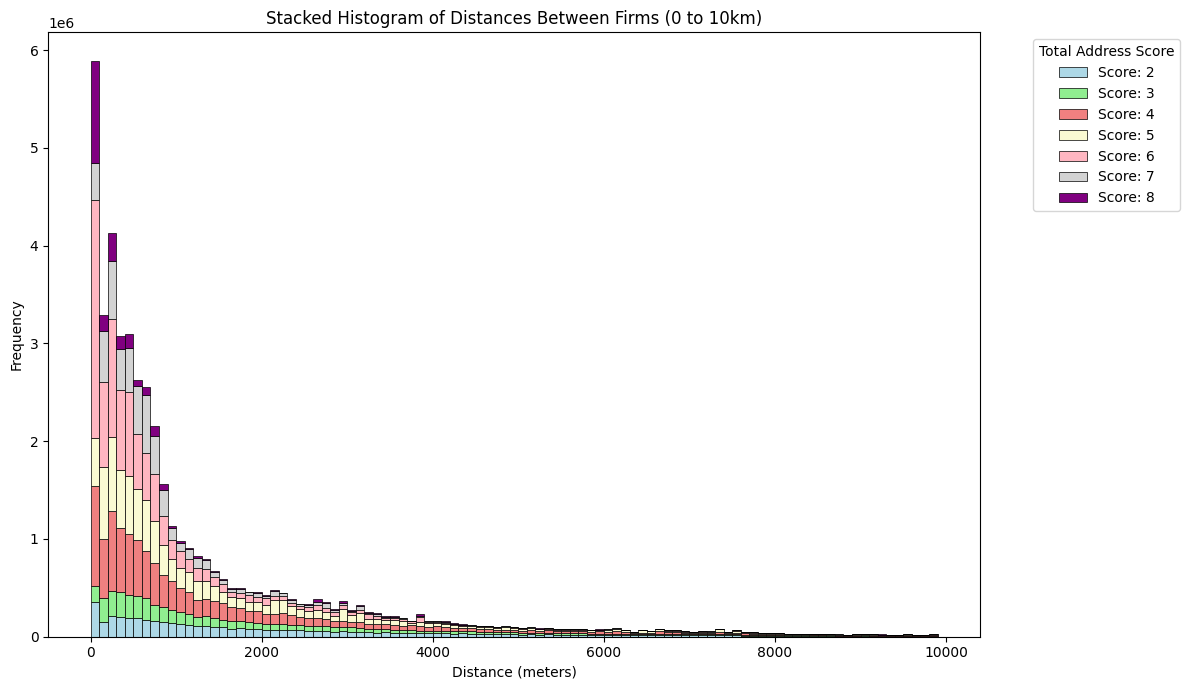

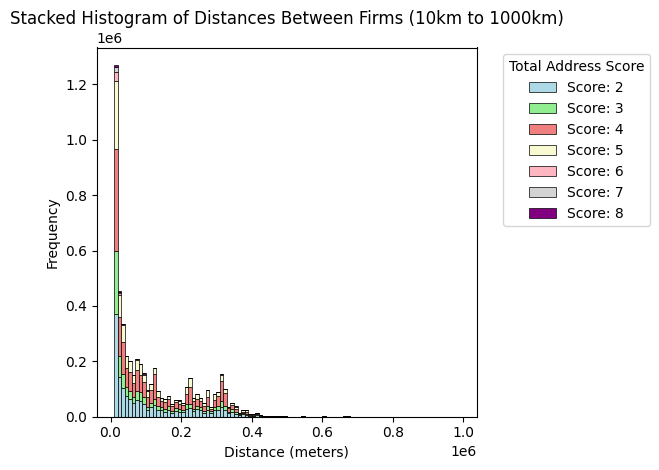

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from ibis import _

# 1. Execute the query and return the FULL DataFrame (both columns)
df_distances = (
    table_joined
    .select(["distance_meters", "address_lvl_i", "address_case_i", "address_lvl_j", "address_case_j"])
    .mutate(
        # Note: Casting the boolean to an integer ensures the multiplication works safely across SQL backends
        address_score_i = _.address_lvl_i + (_.address_case_i == 'ro').cast('int8') * 2,
        address_score_j = _.address_lvl_j + (_.address_case_j == 'ro').cast('int8') * 2,
    )
    .mutate(
        address_score_total = _.address_score_i + _.address_score_j
    )
    .select(["distance_meters", "address_score_total"])
    .execute()
)

# 2. Group the distances by their total score into a list of arrays
# Matplotlib requires the shape: [array(score_1_distances), array(score_2_distances), ...]
unique_scores = sorted(df_distances['address_score_total'].dropna().unique())
data_to_plot = [
    df_distances[df_distances['address_score_total'] == score]['distance_meters'].values 
    for score in unique_scores
]

# Create labels mapping to each array for the legend
labels = [f"Score: {int(score)}" for score in unique_scores]

color_map = [
    'lightblue', 'lightgreen', 'lightcoral', 'lightgoldenrodyellow', 'lightpink', 'lightgray',
    'purple', 'orange', 'cyan', 'magenta', 'yellow', 'brown', 'teal', 'navy', 'olive'
]

# 3. Plot the stacked histogram
plt.figure(figsize=(12, 7))

# Pass the list of arrays, set stacked=True
plt.hist(
    data_to_plot, 
    bins=np.arange(0, 10000, 100), 
    stacked=True, 
    color=color_map[:len(unique_scores)], 
    label=labels,
    edgecolor='black',
    linewidth=0.5
)
plt.title('Stacked Histogram of Distances Between Firms (0 to 10km)')
plt.xlabel('Distance (meters)')
plt.ylabel('Frequency')
plt.legend(title='Total Address Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Ensures the external legend isn't cut off
plt.show()

# Pass the list of arrays, set stacked=True
plt.hist(
    data_to_plot, 
    bins=np.arange(10000, 1000000, 10000), 
    stacked=True, 
    color=color_map[:len(unique_scores)], 
    label=labels,
    edgecolor='black',
    linewidth=0.5
)
plt.title('Stacked Histogram of Distances Between Firms (10km to 1000km)')
plt.xlabel('Distance (meters)')
plt.ylabel('Frequency')
plt.legend(title='Total Address Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Ensures the external legend isn't cut off
plt.show()

In [4]:
# ==========================================
# CELL 2: SINGLE FIRM "EGO-NETWORK" PREVIEW (PURE IBIS)
# ==========================================
import ibis
import pandas as pd

# Assume connections exist
dist_matrix = con.table("working_distance")
working_fixed = con.table("working_fixed")

# 1. Pick a random firm that has a decent number of peers (20 to 50)
target_firm_expr = (
    dist_matrix
    .group_by(['firm_i', 'pc4'])
    .agg(peer_count=dist_matrix.firm_j.count())
    .filter(lambda t: (t.peer_count >= 20) & (t.peer_count <= 50))
    .limit(1)
)

target_info = target_firm_expr.execute()
target_firm_id = target_info['firm_i'].iloc[0]
target_pc4 = target_info['pc4'].iloc[0]

print(f"Examining Firm: {target_firm_id} (Postcode Sector: {target_pc4})")
print(f"Total peers in sector: {target_info['peer_count'].iloc[0]}")

# 2. Pull this specific firm's network using Ibis Joins
# First, filter the 13M row matrix down to just the ~30 rows for our target firm
ego_edges = dist_matrix.filter(dist_matrix.firm_i == target_firm_id)

# Setup aliases so we can join the working_fixed table to itself twice
w1 = working_fixed.alias("w1") # For the Target Firm's coordinates

Examining Firm: 06853242 (Postcode Sector: LU3)
Total peers in sector: 29


In [11]:
# ==========================================
# CELL 3: INTERACTIVE NETWORK MAPPING (MODULAR & ORM)
# ==========================================
import ibis
import pandas as pd
import folium

# --- USER VARIABLES ---
sample_nb_firms = 5
dist_matrix = con.table("working_distance")
working_fixed = con.table("working_fixed")

# ==========================================
# 1. REUSABLE DATA FETCHING FUNCTION
# ==========================================
def get_ego_networks(firm_ids: list, dist_matrix_tbl: ibis.Table, fixed_tbl: ibis.Table) -> pd.DataFrame:
    """
    Fetches the spatial ego-network for a list of target firms using purely Ibis ORM.
    """
    # Filter the massive distance matrix down to just our target firms
    ego_edges = dist_matrix_tbl.filter(dist_matrix_tbl.firm_i.isin(firm_ids))
    
    # Pre-select and alias the fixed table to cleanly join coordinates 
    # without creating column name collisions
    tf_i = fixed_tbl.select(
        registered_number = fixed_tbl.registered_number,
        lat_i = fixed_tbl.lat_dec,
        lon_i = fixed_tbl.lon_dec
    )
    
    tf_j = fixed_tbl.select(
        registered_number = fixed_tbl.registered_number,
        lat_j = fixed_tbl.lat_dec,
        lon_j = fixed_tbl.lon_dec
    )
    
    # Execute ORM Joins, Selection, and Ordering
    network_expr = (
        ego_edges
        .inner_join(tf_i, ego_edges.firm_i == tf_i.registered_number)
        .inner_join(tf_j, ego_edges.firm_j == tf_j.registered_number)
        .select(
            target_firm = ego_edges.firm_i,
            peer_firm = ego_edges.firm_j,
            pc4 = ego_edges.pc4,
            distance_meters = ego_edges.distance_meters,
            target_lat = tf_i.lat_i,
            target_lon = tf_i.lon_i,
            peer_lat = tf_j.lat_j,
            peer_lon = tf_j.lon_j
        )
        .order_by(ego_edges.distance_meters)
    )
    
    return network_expr.execute()

# ==========================================
# 2. REUSABLE PLOTTING FUNCTION
# ==========================================
def plot_ego_networks(df_networks: pd.DataFrame) -> folium.Map:
    """
    Generates a Folium map plotting multiple firm networks in unique colors.
    """
    if df_networks.empty:
        print("No network data found to plot.")
        return None

    # Center map on the average coordinates of all targets
    center_lat = df_networks['target_lat'].mean()
    center_lon = df_networks['target_lon'].mean()
    m = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles="CartoDB positron")

    unique_targets = df_networks['target_firm'].unique()
    
    # A palette of distinct Folium-supported colors
    colors = [
        'red', 'blue', 'green', 'purple', 'orange', 
        'darkred', 'cadetblue', 'darkgreen', 'darkpurple', 'black'
    ]

    for idx, target_id in enumerate(unique_targets):
        color = colors[idx % len(colors)]
        target_data = df_networks[df_networks['target_firm'] == target_id]

        t_lat = target_data['target_lat'].iloc[0]
        t_lon = target_data['target_lon'].iloc[0]
        t_pc4 = target_data['pc4'].iloc[0]

        # Add Target Firm Marker (Star)
        folium.Marker(
            location=[t_lat, t_lon],
            tooltip=f"<b>TARGET FIRM</b><br>ID: {target_id}<br>PC4: {t_pc4}",
            icon=folium.Icon(color=color, icon="star")
        ).add_to(m)

        max_dist = target_data['distance_meters'].max() or 1 

        # Add Peers and Edges
        for _, row in target_data.iterrows():
            p_lat = row['peer_lat']
            p_lon = row['peer_lon']
            dist = row['distance_meters']
            peer_id = row['peer_firm']
            
            # Peer Marker
            folium.CircleMarker(
                location=[p_lat, p_lon],
                radius=4,
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.6,
                tooltip=f"Peer: {peer_id}<br>Distance: {dist:.1f} m"
            ).add_to(m)
            
            # Spatial Edge (Fades out over distance)
            opacity = max(0.1, 1.0 - (dist / max_dist))
            folium.PolyLine(
                locations=[(t_lat, t_lon), (p_lat, p_lon)],
                color=color,
                weight=1.5,
                opacity=opacity,
                dash_array="5, 5"
            ).add_to(m)

    return m

# ==========================================
# 3. EXECUTION: SAMPLE AND VISUALIZE
# ==========================================
print(f"⏳ Sampling {sample_nb_firms} firms and generating networks...")

# 3a. Create an aggregated view of firms and their peer counts (no maximum bound)
target_firm_expr = (
    dist_matrix
    .group_by('firm_i')
    .agg(peer_count=dist_matrix.firm_j.count())
    .filter(lambda t: t.peer_count >= 10)  # Just ensuring they aren't isolated
)

# 3b. Get row count to calculate the exact sample fraction Ibis needs
row_count = target_firm_expr.count().execute()

# 3c. Sample the IDs. (We add .limit() because .sample() is approximate and might return 6)
sampled_targets_df = (
    target_firm_expr
    .sample(sample_nb_firms / row_count)
    .limit(sample_nb_firms)
)

ref_ttwa = con.read_csv(dirs.input_dir / "TTWA Travel to Work Area names and codes UK as at 12_11 v5.csv")
working_fixed_skinny = working_fixed.select("registered_number", "ttwa", "pc8")
sampled_targets_hydrated = (
    sampled_targets_df
    .inner_join(working_fixed_skinny, sampled_targets_df.firm_i == working_fixed_skinny.registered_number)
    .inner_join(ref_ttwa, ibis._.ttwa == ref_ttwa.TTWA11CD)
    .execute()
)

target_ids = sampled_targets_hydrated['firm_i'].tolist()
print(f"🎯 Selected Target Firms: {target_ids}")

# 3d. Fetch data using our reusable function
df_multi_network = get_ego_networks(target_ids, dist_matrix, working_fixed)
# For every row in hydrated, print its ttwa and number of peers fetched
for row in sampled_targets_hydrated.itertuples():
    target_id = row.firm_i
    peer_count = len(df_multi_network[df_multi_network['target_firm'] == target_id])
    print(f"✅ Fetched {peer_count} edges for target firm {target_id} in {row.TTWA11NM}.")

# 3e. Generate and display the map using our reusable function
network_map = plot_ego_networks(df_multi_network)

# Display network_map in out_dir as an html
out_path = dirs.output_dir / "ego_network_map.html"
print(f"⏳ Saving ego-network map to {out_path}")
network_map.save(out_path)

⏳ Sampling 5 firms and generating networks...
🎯 Selected Target Firms: ['05559173', '03617412', '01350236', '05915098', '08898792']
✅ Fetched 761 edges for target firm 05559173 in London.
✅ Fetched 69 edges for target firm 03617412 in Norwich.
✅ Fetched 402 edges for target firm 01350236 in London.
✅ Fetched 1156 edges for target firm 05915098 in London.
✅ Fetched 455 edges for target firm 08898792 in London.
⏳ Saving ego-network map to C:\Users\lazyst\Files\ucl\Dissertation\descriptives\output\ego_network_map.html
